In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Image Compression

In this challenge, we will use **images** 🖼️ as data.

Using **K-means** for image compression, you will reduce the colors in an image to only the most frequently used ones.

## 1) Images in Python

This section will help you understand how we work with images in Python.  

**No coding required for section 1 — read carefully and run the given examples.**

### 1.1) Black & white images

An image can be defined as a matrix where each element is a pixel.  

The color scale ranges from 0 (black) to 255 (white).  

So each element in the matrix will have a value between 0 and 255.

<img src="https://miro.medium.com/max/1386/1*bV7S0zACdidh11ikjYpLpQ.png">

We said "matrix", you thought "numpy" — correct 🙂  

👇 Run the cell below to see a black & white image created using only `numpy`.

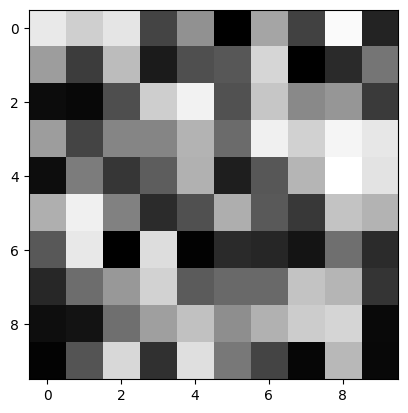

In [2]:
# Create a vector of 100 elements with values between 0 and 255.
image_bw = np.random.uniform(low=0, high=255, size=100)

# Reshape into a square matrix — we get a 10x10 pixel image.
image_bw = image_bw.reshape((10, 10))

# Display the resulting image
plt.imshow(image_bw, cmap='gray');

### 1.2) Color images :

Each color is a linear combination of primary colors: Red, Green, Blue  

A color image is formed by stacking three layers, one for each primary color.  

So for each pixel we have three values (Red, Green, Blue).

<img src="https://miro.medium.com/max/840/1*y0nV4cWk3KbzXSe9dIWL5g.jpeg">

👇  Again, run the cells below to see a color image created using only `numpy`.

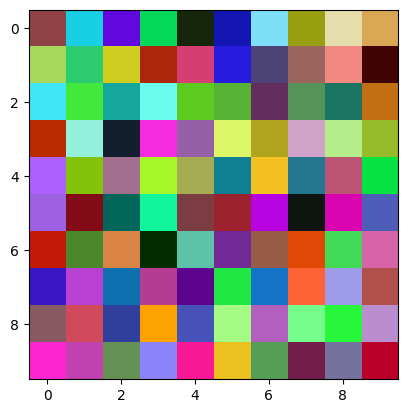

In [3]:
# Create a vector of 100*3 elements with values between 0 and 1.
image_c = np.random.uniform(low=0., high=1., size=100*3)

# Reshape into a square image of 10x10 pixels with 3 color channels.
image_c = image_c.reshape((10, 10, 3))

# Display the resulting image
plt.imshow(image_c);

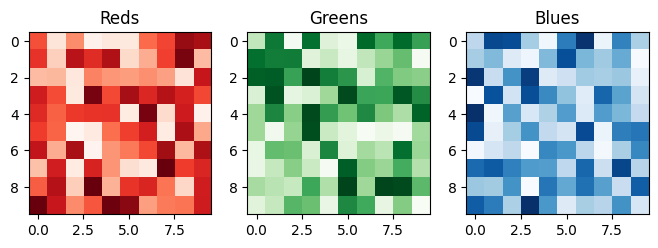

In [4]:
# To get an intuitive feel, let's plot each color channel separately.
fig, axs = plt.subplots(1, 3, figsize=(8, 6))
colors = {0:'Reds', 1:'Greens', 2:'Blues'}

for i in colors:
    axs[i].imshow(image_c[:, :, i], cmap=colors[i])
    axs[i].set_title(colors[i])

## 2) Images for ML

### 2.1) Setup

Install the `skimage` library, which gives us access to classic images.

In [5]:
! pip install --quiet scikit-image

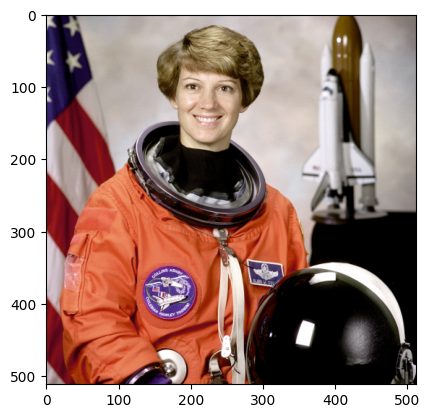

In [6]:
from skimage import data
img = data.astronaut()
plt.imshow(img);

❓ What is the shape of this image?  
Assign it to `img_shape`

In [7]:
img_shape = img.shape
img_shape

(512, 512, 3)

### 2.2) Color count

To prepare our image for compression or machine learning in general, we need to represent it as **observations** and **features**.  

Each **pixel** is an **observation**  
Each **color value (Red, Green, Blue)** is a **feature**  

Our image has **262,144 observations** (512 * 512 pixels) and **3 features** (RGB).

❓ Reshape the image:  
- From its current 3D shape `width x height x 3`
- To a 2D matrix of shape `n_pixels x 3`, where `n_pixels = width * height`  

Assign the reshaped image to `X`.

In [8]:
n_pixels = img.shape[0] * img.shape[1]

X = img.reshape(n_pixels, 3)
X.shape

(262144, 3)

A color image can contain up to 16 million potential colors.  

Indeed, we have **3** channels per pixel and **256** possible values per channel (from 0 to 255).  
So a color image can potentially have a maximum of **16,777,216** *($256^3$)* colors.  

Since our image is only 262,144 pixels (512 * 512), and each pixel contains a single color defined by its three channel values, it uses at most 262,144 colors.

Let's count! 🕵️

❓ Store the number of unique colors in this image in `color_count`.

In [9]:
color_count = len(np.unique(X, axis=0))
color_count

113382

Let's review what we have:
- 262,144 observations, each observation is a pixel
- 3 features per observation (Red, Green, and Blue values)
- An unknown number of clusters 😱

**Let's see what we can do to reduce the number of colors** 🎨

### 🧪 Test Your Code

In [10]:
from nbresult import ChallengeResult

result = ChallengeResult('image_analysis',
                         img_shape = img_shape,
                         color_count = color_count)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-image-compressor/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 2 items

test_image_analysis.py::TestImageAnalysis::test_color_count PASSED       [ 50%]
test_image_analysis.py::TestImageAnalysis::test_img_shape PASSED         [100%]

============================== 2 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/image_analysis.pickle

git commit -m 'Completed image_analysis step'

git push origin master



## 3) Compression with K-means

We want to reduce **113,382** colors down to **K** colors.  

By using the `KMeans` algorithm on the pixels, we can assign each pixel to one of **K** clusters!  

The center of each cluster will be the average color of the pixels belonging to that cluster.  

We can then use this "average cluster color" as the RGB value for every pixel in that cluster.  

💪🧠 Let's get started — our goal is to use only **32** colors!

❓ Fit a K-means with `n_clusters=32` on your ML-ready image `X` and assign it to `kmeans`.

In [ ]:
# YOUR CODE HERE

👉 Check the `labels_` of your `kmeans`, then check its `shape` and `number of unique values`.

In [ ]:
# YOUR CODE HERE

☝️ Let's break this down:

- Each label is a cluster
- Each observation has been assigned a label
- There are 32 different labels in total, one per cluster

❓ Check the `cluster_centers_` of your `KMeans`, its shape, and its first element.

In [ ]:
# YOUR CODE HERE

☝️ Each cluster_center is a vector of RGB values representing the average color of the cluster.

❓ Build the `X_compressed` array that stores the average color of the corresponding cluster for each pixel image.

<details span="markdown">
    <summary>💡 Hint</summary>

You can achieve this using only `kmeans.cluster_centers_` and `kmeans.labels_`.

---

</details>

In [ ]:
# YOUR CODE HERE

RGB values must be integers.  

The colors in `X_compressed` are of type `float64`.  

❓ Convert the type of `X_compressed` to `uint8`, the unsigned 8-bit integer type ranging from 0 to 255.

In [ ]:
# YOUR CODE HERE

❓ Verify that the number of unique colors used is indeed 32.

In [ ]:
# YOUR CODE HERE

Almost there! 💪

## 4) Plot the compressed image

Since our `X_compressed` has shape (262144, 3), we cannot display it as an image.

❓ Reshape your compressed image and plot it side by side with the original image.  

<details>
    <summary>💡 Hint</summary>

You need to reshape your flattened `X_compressed` back to the correct dimensions for an image.  
Your original image has those dimensions.

---

</details>

In [ ]:
# YOUR CODE HERE

Well done! 💪

Some colors are lost, but you can still easily recognize the original image.

🏁 **Don't forget to push your notebook.**  

Complete the day's tasks and come back here if you have time 😉

## 5 - Optional) Use the elbow method

You can try using the elbow method to find the optimal compression that loses the least color information.   

For example, try plotting the `inertia` for `n_clusters` in the list [5, 10, 20, 30, 50, 70, 100].  

⚠️ Long training time — you may need to wait a few minutes.

In [ ]:
# YOUR CODE HERE

❓ Run the cell below to visualize your compressed image using different numbers of clusters  
⚠️ This is a long training run — you will need to wait a few minutes

In [ ]:
wcss = []
compressed_astronaut = []
for i in [1, 2, 5, 10, 20, 30, 50, 70, 100]:
    print('working with ' + str(i) + ' clusters...', flush=True)
    kmeans = KMeans(n_clusters = i, max_iter=10)
    kmeans.fit(X)
    # compute inertia
    wcss.append(kmeans.inertia_)
    # compute compressed astronaut
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    X_compressed = centers[labels]
    X_compressed = X_compressed.astype('uint8')
    img_compressed = X_compressed.reshape(img_shape[0], img_shape[1], img_shape[2])
    compressed_astronaut.append(img_compressed)
    # print
    print("-"*120)
    print(f"If we compress our 113382 unique colors into {i} clusters...")
    print(f"The Kmeans inertia is equal to {kmeans.inertia_}")
    fig, ax = plt.subplots(1, 2, figsize = (7, 7))
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[1].imshow(img_compressed)
    ax[1].set_title('Compressed Image')
    for ax in fig.axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()